In [ ]:
!nvidia-smi

Tue Jun 23 12:27:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   59C    P8             18W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 85 (delta 30), reused 33 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 28.11 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [ ]:
pip install torchattacks

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [ ]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [ ]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  15.3M      0  0:00:17  0:00:17 --:--:-- 19.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  8258k      0  0:00:10  0:00:10 --:--:-- 9718k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  87912      0  0:00:01  0:00:01 --:--:-- 87925


In [ ]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [ ]:
import shutil

In [ ]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [ ]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [ ]:
batch_size = 10

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

# batch_size = 32

# trainset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/Final_Training/Images',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.RandomApply([
#             transforms.RandomAffine(
#                 degrees=12,
#                 translate=(0.05, 0.05),
#                 scale=(0.9, 1.1),
#                 shear=6,
#             )
#         ], p=0.6),
#         transforms.RandomPerspective(distortion_scale=0.18, p=0.25),
#         transforms.ColorJitter(
#             brightness=0.30,
#             contrast=0.30,
#             saturation=0.20,
#             hue=0.03,
#         ),
#         transforms.RandomApply([
#             transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
#         ], p=0.12),
#         transforms.ToTensor(),
#         transforms.RandomErasing(
#             p=0.12,
#             scale=(0.01, 0.05),
#             ratio=(0.3, 3.3),
#             value='random',
#         ),
#     ])
# )

# testset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/test',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#     ])
# )

# train_loader = torch.utils.data.DataLoader(
#     dataset=trainset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=2,
#     pin_memory=True,
# )

# test_loader = torch.utils.data.DataLoader(
#     dataset=testset,
#     batch_size=batch_size * 2,
#     shuffle=False,
#     num_workers=2,
#     pin_memory=True,
# )

In [ ]:
batch = next(iter(train_loader))
train_data = batch[0]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

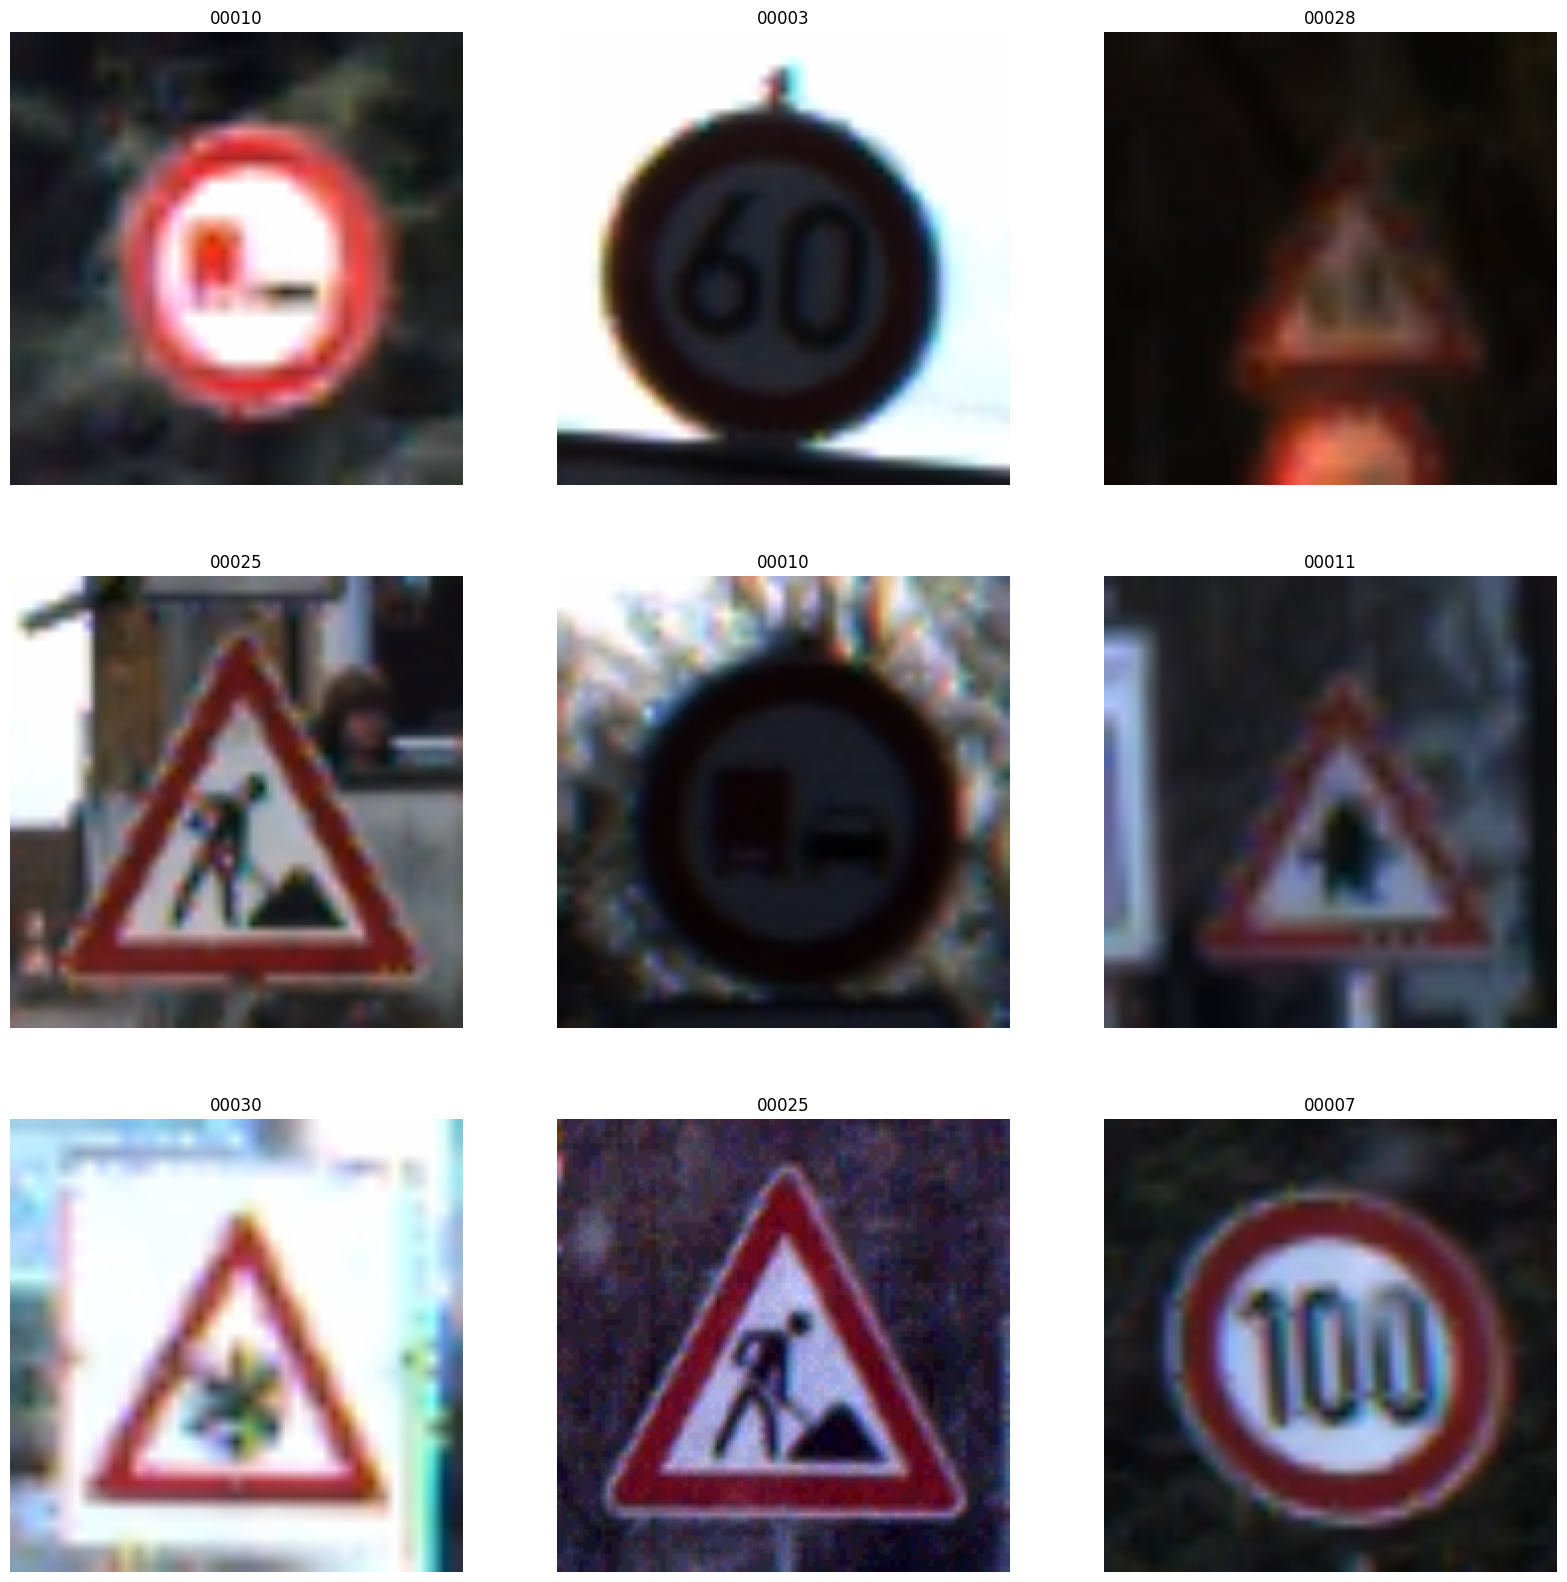

In [ ]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [ ]:
pip install timm

In [ ]:
pip install einops

In [ ]:
# from LNL import LNL_Ti as small

from LNL_TS import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [ ]:
model = small(pretrained=False)

In [ ]:
model.head

Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

## Train Locality-iN-Locality

In [ ]:
num_epochs = 25

In [ ]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [ ]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/25], lter [200/3920], Loss: 3.261794
Epoch [1/25], lter [400/3920], Loss: 2.147375
Epoch [1/25], lter [600/3920], Loss: 1.145606
Epoch [1/25], lter [800/3920], Loss: 1.019878
Epoch [1/25], lter [1000/3920], Loss: 0.903429
Epoch [1/25], lter [1200/3920], Loss: 0.433920
Epoch [1/25], lter [1400/3920], Loss: 0.479233
Epoch [1/25], lter [1600/3920], Loss: 0.426774
Epoch [1/25], lter [1800/3920], Loss: 0.438892
Epoch [1/25], lter [2000/3920], Loss: 0.425133
Epoch [1/25], lter [2200/3920], Loss: 0.475520
Epoch [1/25], lter [2400/3920], Loss: 0.413256
Epoch [1/25], lter [2600/3920], Loss: 0.434682
Epoch [1/25], lter [2800/3920], Loss: 0.428165
Epoch [1/25], lter [3000/3920], Loss: 0.521247
Epoch [1/25], lter [3200/3920], Loss: 0.460206
Epoch [1/25], lter [3400/3920], Loss: 0.417006
Epoch [1/25], lter [3600/3920], Loss: 0.462017
Epoch [1/25], lter [3800/3920], Loss: 0.397630
Epoch [2/25], lter [200/3920], Loss: 0.419506
Epoch [2/25], lter [400/3920], Loss: 0.480720
Epoch [2/25], lter 

## Test

In [ ]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.12 %


## FGSM attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 87.45 %


## PGD attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 46.41 %


## Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [ ]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth')

import shutil
from google.colab import files

shutil.make_archive('/content/data', 'zip', '/content/Locality-iN-Locality/data')
shutil.make_archive('/content/pretrained', 'zip', '/content/Locality-iN-Locality/pretrained')

# files.download('/content/data.zip')
files.download('/content/pretrained.zip')

Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [ ]:
from LNL_TS import LNL_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

Loaded pretrained LNL-TS model successfully


 ## Print top-1 and top-5: LNL_Ti

In [ ]:
from LNL_TS import LNL_Ti as small
import torch

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

model = small(pretrained=True)
model = model.cuda()
model.eval()

correct_1 = 0
correct_5 = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)

        # Top-1 accuracy
        predicted_1 = outputs.argmax(dim=1)
        correct_1 += predicted_1.eq(labels).sum().item()

        # Top-5 accuracy
        _, predicted_5 = outputs.topk(5, 1, True, True)
        correct_5 += (predicted_5 == labels.view(-1, 1)).sum().item()

        total += labels.size(0)

print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct_1 / total))
print('Reloaded pretrained Top-5 accuracy: %.2f %%' % (100.0 * correct_5 / total))

Reloaded pretrained Top-1 accuracy: 99.12 %
Reloaded pretrained Top-5 accuracy: 99.79 %


### Train LNL-MoEx

In [ ]:
# from LNL_MoEx import LNL_MoEx_Ti as small
from LNL_TS import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

In [ ]:
import time
# time.clock_gettime()

In [ ]:
num_epochs = 25
moex_lam = .9
moex_prob = .7

In [ ]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [ ]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/25], lter [200/3920], Loss: 3.044077
Epoch [1/25], lter [400/3920], Loss: 2.387132
Epoch [1/25], lter [600/3920], Loss: 2.063004
Epoch [1/25], lter [800/3920], Loss: 1.243224
Epoch [1/25], lter [1000/3920], Loss: 1.236255
Epoch [1/25], lter [1200/3920], Loss: 1.186989
Epoch [1/25], lter [1400/3920], Loss: 1.035278
Epoch [1/25], lter [1600/3920], Loss: 0.986804
Epoch [1/25], lter [1800/3920], Loss: 0.414517
Epoch [1/25], lter [2000/3920], Loss: 1.054975
Epoch [1/25], lter [2200/3920], Loss: 0.414433
Epoch [1/25], lter [2400/3920], Loss: 1.021446
Epoch [1/25], lter [2600/3920], Loss: 0.953281
Epoch [1/25], lter [2800/3920], Loss: 0.834731
Epoch [1/25], lter [3000/3920], Loss: 0.708692
Epoch [1/25], lter [3200/3920], Loss: 0.818059
Epoch [1/25], lter [3400/3920], Loss: 0.940111
Epoch [1/25], lter [3600/3920], Loss: 0.947427
Epoch [1/25], lter [3800/3920], Loss: 0.413868
Epoch [2/25], lter [200/3920], Loss: 0.874288
Epoch [2/25], lter [400/3920], Loss: 1.008172
Epoch [2/25], lter 

### Test

In [ ]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.03 %


### FGSM attack

In [ ]:
model.eval()
correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy (FGSM): %.2f %%' % (100 * float(correct) / total))

Robust accuracy (FGSM): 74.81 %


### PGD attack

In [ ]:
model.eval()
correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy (PGD): %.2f %%' % (100 * float(correct) / total))

Robust accuracy (PGD): 29.49 %


### Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [ ]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_moex_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_moex_ti_gtsrb.pth')

import shutil
from google.colab import files

shutil.make_archive('/content/data', 'zip', '/content/Locality-iN-Locality/data')
shutil.make_archive('/content/pretrained', 'zip', '/content/Locality-iN-Locality/pretrained')

# files.download('/content/data.zip')
files.download('/content/pretrained.zip')

Saved pretrained model to pretrained/lnl_ts_moex_ti_gtsrb.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [ ]:
from LNL_TS import LNL_MoEx_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

Loaded pretrained LNL-TS model successfully


 ### Print top-1 and top-5: LNL_MoEx_Ti

In [ ]:
from LNL_TS import LNL_MoEx_Ti as small
import torch

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

model = small(pretrained=True)
model = model.cuda()
model.eval()

correct_1 = 0
correct_5 = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)

        # Top-1 accuracy
        predicted_1 = outputs.argmax(dim=1)
        correct_1 += predicted_1.eq(labels).sum().item()

        # Top-5 accuracy
        _, predicted_5 = outputs.topk(5, 1, True, True)
        correct_5 += (predicted_5 == labels.view(-1, 1)).sum().item()

        total += labels.size(0)

print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct_1 / total))
print('Reloaded pretrained Top-5 accuracy: %.2f %%' % (100.0 * correct_5 / total))

Reloaded pretrained Top-1 accuracy: 99.12 %
Reloaded pretrained Top-5 accuracy: 99.79 %


## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-gfkqu0nq
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-gfkqu0nq
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


TrafficSignLNL(
  6.04 M, 99.371% Params, 1.25 GMac, 99.682% MACs, 
  (pixel_embed): PixelEmbed(
    1.27 k, 0.021% Params, 10.91 MMac, 0.871% MACs, 
    (proj): TrafficSignStem(
      1.27 k, 0.021% Params, 10.91 MMac, 0.871% MACs, 
      (conv1): Conv2d(648, 0.011% Params, 8.13 MMac, 0.649% MACs, 3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(48, 0.001% Params, 602.11 KMac, 0.048% MACs, 24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(0, 0.000% Params, 301.06 KMac, 0.024% MACs, approximate='none')
      (dwconv): Conv2d(216, 0.004% Params, 677.38 KMac, 0.054% MACs, 24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
      (bn2): BatchNorm2d(48, 0.001% Params, 150.53 KMac, 0.012% MACs, 24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): GELU(0, 0.000% Params, 75.26 KMac, 0.006% MACs, approximate='none')
      (pwconv): Conv2d(288, 0.005% Par

## Fine-tune current best LNL-TS toward 99.5%+

This section continues from the current best non-MoEx checkpoint (`99.24%` in this notebook). It uses mild augmentation, low learning rate, EMA, and deterministic multi-scale TTA for checkpoint selection. Save the best model as `pretrained/lnl_ts_ti_gtsrb_finetuned.pth`.


In [ ]:
import copy
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

from LNL_TS import LNL_Ti as small

os.makedirs('pretrained', exist_ok=True)

finetune_train_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=5,
            translate=(0.02, 0.02),
            scale=(0.96, 1.04),
            shear=2,
            interpolation=InterpolationMode.BILINEAR,
        )
    ], p=0.35),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.01),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
])

def tta_transform(image):
    to_tensor = transforms.ToTensor()
    crops = []
    for resize_size in (224, 240, 256):
        resized = transforms.Resize((resize_size, resize_size), interpolation=InterpolationMode.BICUBIC)(image)
        if resize_size == 224:
            crops.append(to_tensor(resized))
        else:
            crops.extend(to_tensor(crop) for crop in transforms.FiveCrop(224)(resized))
    return torch.stack(crops)

finetune_trainset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/Final_Training/Images',
    transform=finetune_train_transform,
)
clean_testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test', transform=eval_transform)
tta_testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test', transform=tta_transform)

finetune_batch_size = 32
finetune_train_loader = torch.utils.data.DataLoader(
    finetune_trainset, batch_size=finetune_batch_size, shuffle=True, num_workers=2, pin_memory=True
)
clean_test_loader = torch.utils.data.DataLoader(
    clean_testset, batch_size=finetune_batch_size * 2, shuffle=False, num_workers=2, pin_memory=True
)
tta_test_loader = torch.utils.data.DataLoader(
    tta_testset, batch_size=finetune_batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print('Fine-tune train/test sizes:', len(finetune_trainset), len(clean_testset))


Fine-tune train/test sizes: 39209 12630


In [ ]:
class ModelEma:
    def __init__(self, model, decay=0.9995):
        self.module = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_state = self.module.state_dict()
        model_state = model.state_dict()
        for key, value in ema_state.items():
            model_value = model_state[key].detach()
            if value.dtype.is_floating_point:
                value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
            else:
                value.copy_(model_value)

@torch.no_grad()
def evaluate_topk(model, loader, use_tta=False):
    model.eval()
    correct_1 = 0
    correct_5 = 0
    total = 0
    for images, labels in loader:
        labels = labels.cuda(non_blocking=True)
        if use_tta:
            b, crops, c, h, w = images.shape
            images = images.view(b * crops, c, h, w).cuda(non_blocking=True)
            outputs = model(images).view(b, crops, -1).mean(dim=1)
        else:
            images = images.cuda(non_blocking=True)
            outputs = model(images)
        pred_1 = outputs.argmax(dim=1)
        _, pred_5 = outputs.topk(5, 1, True, True)
        total += labels.size(0)
        correct_1 += pred_1.eq(labels).sum().item()
        correct_5 += (pred_5 == labels.view(-1, 1)).sum().item()
    return 100.0 * correct_1 / total, 100.0 * correct_5 / total


In [ ]:
model = small(pretrained=True).cuda()
ema = ModelEma(model, decay=0.9995)

criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=2e-2)
num_finetune_epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_finetune_epochs)
scaler = torch.cuda.amp.GradScaler()

best_tta_top1 = 0.0
best_clean_top1 = 0.0
best_state = None

for epoch in range(num_finetune_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in finetune_train_loader:
        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss_value = criterion(outputs, labels)
        scaler.scale(loss_value).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        running_loss += loss_value.item() * labels.size(0)

    scheduler.step()
    train_loss = running_loss / len(finetune_trainset)
    clean_top1, clean_top5 = evaluate_topk(ema.module, clean_test_loader, use_tta=False)
    tta_top1, tta_top5 = evaluate_topk(ema.module, tta_test_loader, use_tta=True)

    print(
        f'Epoch [{epoch + 1}/{num_finetune_epochs}] loss={train_loss:.4f} '
        f'clean_top1={clean_top1:.2f} clean_top5={clean_top5:.2f} '
        f'tta_top1={tta_top1:.2f} tta_top5={tta_top5:.2f}'
    )

    if tta_top1 > best_tta_top1:
        best_tta_top1 = tta_top1
        best_clean_top1 = clean_top1
        best_state = copy.deepcopy(ema.module.state_dict())
        torch.save(best_state, 'pretrained/lnl_ts_ti_gtsrb_finetuned.pth')
        print(f'Saved new fine-tuned best: clean={best_clean_top1:.2f} tta={best_tta_top1:.2f}')

print(f'Best fine-tuned clean Top-1: {best_clean_top1:.2f} %')
print(f'Best fine-tuned TTA Top-1: {best_tta_top1:.2f} %')


/tmp/ipykernel_121317/3761857083.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_121317/3761857083.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/20] loss=0.1711 clean_top1=99.20 clean_top5=99.79 tta_top1=99.37 tta_top5=99.81
Saved new fine-tuned best: clean=99.20 tta=99.37
Epoch [2/20] loss=0.1704 clean_top1=99.17 clean_top5=99.73 tta_top1=99.35 tta_top5=99.79


/tmp/ipykernel_121317/3761857083.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_121317/3761857083.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_121317/3761857083.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [3/20] loss=0.1694 clean_top1=99.21 clean_top5=99.75 tta_top1=99.37 tta_top5=99.82
Saved new fine-tuned best: clean=99.21 tta=99.37
Epoch [4/20] loss=0.1694 clean_top1=99.19 clean_top5=99.79 tta_top1=99.39 tta_top5=99.85
Saved new fine-tuned best: clean=99.19 tta=99.39
Epoch [5/20] loss=0.1710 clean_top1=99.10 clean_top5=99.87 tta_top1=99.30 tta_top5=99.92
Epoch [6/20] loss=0.1702 clean_top1=99.19 clean_top5=99.88 tta_top1=99.33 tta_top5=99.91
Epoch [7/20] loss=0.1706 clean_top1=99.29 clean_top5=99.93 tta_top1=99.43 tta_top5=99.95
Saved new fine-tuned best: clean=99.29 tta=99.43
Epoch [8/20] loss=0.1694 clean_top1=99.30 clean_top5=99.92 tta_top1=99.51 tta_top5=99.98
Saved new fine-tuned best: clean=99.30 tta=99.51
Epoch [9/20] loss=0.1697 clean_top1=99.24 clean_top5=99.88 tta_top1=99.45 tta_top5=99.98
Epoch [10/20] loss=0.1697 clean_top1=99.26 clean_top5=99.89 tta_top1=99.49 tta_top5=99.95
Epoch [11/20] loss=0.1694 clean_top1=99.28 clean_top5=99.90 tta_top1=99.54 tta_top5=99.95
S

In [ ]:
from LNL_TS import LNL_Ti as small

model = small(pretrained='pretrained/lnl_ts_ti_gtsrb_finetuned.pth').cuda()
model.eval()
clean_top1, clean_top5 = evaluate_topk(model, clean_test_loader, use_tta=False)
tta_top1, tta_top5 = evaluate_topk(model, tta_test_loader, use_tta=True)
print('Fine-tuned clean Top-1: %.2f %%' % clean_top1)
print('Fine-tuned clean Top-5: %.2f %%' % clean_top5)
print('Fine-tuned TTA Top-1: %.2f %%' % tta_top1)
print('Fine-tuned TTA Top-5: %.2f %%' % tta_top5)


Fine-tuned clean Top-1: 99.28 %
Fine-tuned clean Top-5: 99.90 %
Fine-tuned TTA Top-1: 99.54 %
Fine-tuned TTA Top-5: 99.95 %
